# Trajectory data

A continuation or transient solver returns **trajectories**: one per design, each a chain of closely spaced states parametrised by a time-like coordinate — arc length along a load path, time in a transient, a continuation parameter. Every stored point carries a gradient in all inputs, that coordinate included.

Fitting a surrogate to this takes four steps:

1. Scale the trajectory axis so it is commensurate with the design spacing.
2. Estimate a coordinate frame in the scaled space.
3. Choose the basis size and shape parameter.
4. Predict, and map gradients back through both transforms.

This notebook walks through all four.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ge_rbf import (
    IsotropicTransformer,
    RBFRegressor,
    TrajectoryScaler,
    basis_search,
    plot_basis_search,
    scaled_epsilons,
)
from ge_rbf.problems import load_path, load_path_samples, random_rotation

Z, groups = load_path_samples()
y, dy = load_path(Z, rotation=random_rotation(3, rng=5))

print(f"Z  {Z.shape}   design variables first, trajectory coordinate last")
print(f"dy {dy.shape}   one derivative per input")
print(f"groups {groups.shape}  {np.unique(groups).size} trajectories, "
      f"{np.bincount(groups)[0]} points each")

# Hold four whole designs back, so the accuracy reported at the end is honest.
unseen = np.unique(groups)[-4:]
test = np.isin(groups, unseen)
train = ~test
print(f"\n{train.sum()} rows for fitting, {test.sum()} rows from {len(unseen)} unseen designs")

Z  (270, 4)   design variables first, trajectory coordinate last
dy (270, 4)   one derivative per input
groups (270,)  15 trajectories, 18 points each

198 rows for fitting, 72 rows from 4 unseen designs


## 1. Scale the trajectory axis

Consecutive points along one trajectory sit far closer together than any two designs, so every point's nearest neighbours are its own trajectory's — which is what the curvature estimate in step 2 has to work with. `TrajectoryScaler` stretches that axis until one step along it is `stretch` times the distance between neighbouring designs.

Pass `groups` explicitly for anything a solver produced. Leaving it out infers trajectories by comparing design rows exactly, which fails as soon as each row carries its own round-off.

In [2]:
scaler = TrajectoryScaler().fit(Z[train], groups=groups[train])

Zs_train = scaler.transform(Z[train])
Zs_test = scaler.transform(Z[test])

print(f"design_spacing_ {scaler.design_spacing_:.4f}")
print(f"step_spacing_   {scaler.step_spacing_:.4f}")
print(f"scale_          {scaler.scale_:.3f}")

design_spacing_ 0.3263
step_spacing_   0.0576
scale_          8.494


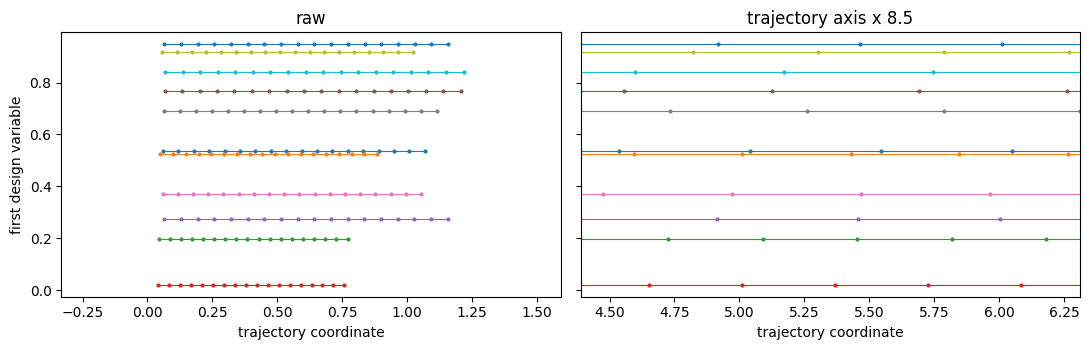

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, points, title in (
    (axes[0], Z[train], "raw"),
    (axes[1], Zs_train, f"trajectory axis x {scaler.scale_:.1f}"),
):
    for g in np.unique(groups[train]):
        on_path = groups[train] == g
        ax.plot(points[on_path, -1], points[on_path, 0], ".-", markersize=4, linewidth=0.8)
    ax.set_xlabel("trajectory coordinate")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")

axes[0].set_ylabel("first design variable")
fig.tight_layout()

Stretching an axis rescales the derivative along it, so the sampled gradients need converting too. Every transformer in the package pairs `transform` with `transform_gradient`, and skipping the second is silent — the values stay right and the fit is handed gradients from a different coordinate system.

In [4]:
dys_train = scaler.transform_gradient(dy[train])

# Both maps round trip exactly.
print(f"inverse_transform recovers Z:            "
      f"{np.allclose(scaler.inverse_transform(Zs_train), Z[train])}")
print(f"inverse_transform_gradient recovers dy:  "
      f"{np.allclose(scaler.inverse_transform_gradient(dys_train), dy[train])}")

inverse_transform recovers Z:            True
inverse_transform_gradient recovers dy:  True


## 2. Estimate the frame

Same as `03_transformations.ipynb`, but fitted on the scaled coordinates. Use `fallback=True` here: local Hessians are positive definite only where the response is locally convex, and a trajectory through a limit point need not be, so `ge-lhm` sometimes has no frame to return. The retreat records what actually worked on `method_`.

In [5]:
frame = IsotropicTransformer(method="ge-lhm", fallback=True).fit(Zs_train, dy=dys_train)

X_train = frame.transform(Zs_train)
dy_train = frame.transform_gradient(dys_train)
X_test = frame.transform(Zs_test)

print(f"method_     {frame.method_}")
print(f"scaling_    {np.round(frame.scaling_, 3)}")
print(f"anisotropy  {frame.eigenvalues_[0] / frame.eigenvalues_[-1]:.1f}x")

method_     ge-lhm
scaling_    [4.766 3.458 0.627 0.576]
anisotropy  68.4x


## 3. Choose the basis

Two things to set: how many basis functions, and how wide. `basis_search` searches both together.

- `scaled_epsilons` expresses the shape parameter relative to the sample spacing. Use it after a frame, where the coordinates are no longer of order one.
- `groups` makes the folds hold out whole trajectories rather than individual rows.
- `centers` on the returned model is an integer count; the centres themselves are drawn space-filling over the samples at fit time.

In [6]:
result = basis_search(
    RBFRegressor(),
    X_train,
    y[train],
    dy_train,
    epsilons=scaled_epsilons(X_train, np.logspace(-2, 4, 15)),
    groups=groups[train],
    k=5,
)

model = result.best_estimator

print(result)
print(f"\ncentres  {model.centers_.shape[0]}")
print(f"epsilon  {model.epsilon:.4g}")
print(f"mode     {model.mode_}")
print(f"condition {model.condition_:.2e}")

BasisSearchResult(best_n_centers=42, best_epsilon=0.05004, best_score=0.458, grid=8x15, rejected=43, n_samples=198)

centres  42
epsilon  0.05004
mode     ge
condition 1.00e+05


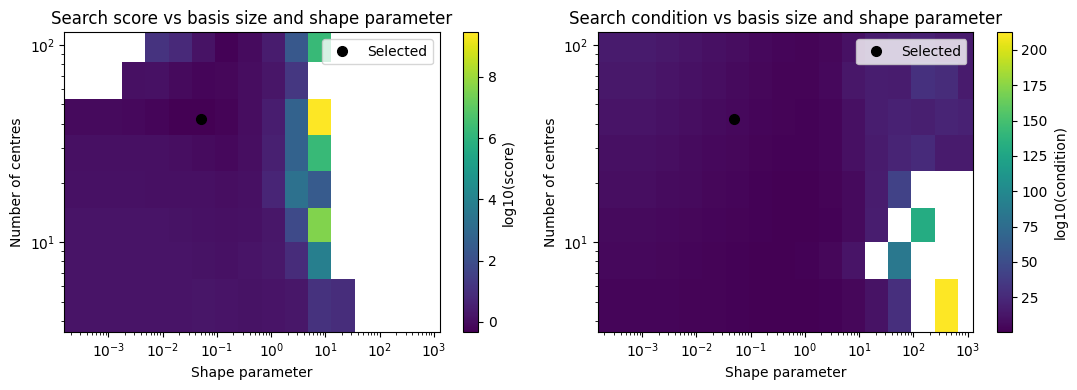

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_basis_search(result, ax=axes[0])
plot_basis_search(result, ax=axes[1], values="condition")
fig.tight_layout()

## 4. Predict

Predictions come out in the fitting coordinates, so gradients have to travel back through both transforms — the frame first, then the trajectory axis. Function values need no conversion.

In [8]:
predicted, predicted_gradient = model.predict(X_test, return_gradient=True)

# Frame first, then the trajectory axis.
predicted_gradient = scaler.inverse_transform_gradient(
    frame.inverse_transform_gradient(predicted_gradient)
)

value_error = np.linalg.norm(predicted - y[test]) / np.linalg.norm(y[test])
print(f"response, on {len(unseen)} unseen designs: {value_error:.2%}\n")

labels = [f"d/dx{i + 1}" for i in range(Z.shape[1] - 1)] + ["d/ds"]
for j, label in enumerate(labels):
    error = np.linalg.norm(predicted_gradient[:, j] - dy[test][:, j]) / np.linalg.norm(
        dy[test][:, j]
    )
    print(f"{label:>6}  {error:.2%}")

response, on 4 unseen designs: 15.98%

 d/dx1  19.27%
 d/dx2  21.28%
 d/dx3  28.37%
  d/ds  19.45%


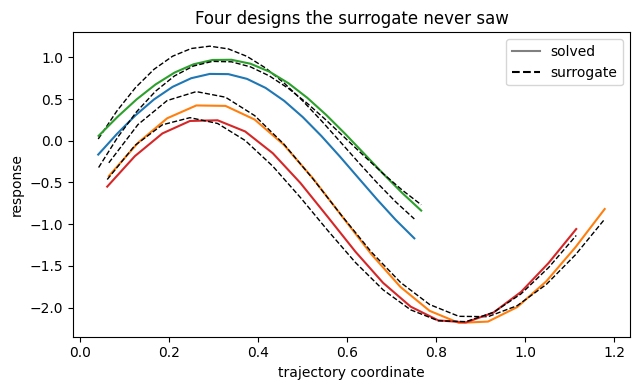

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))

for g in unseen:
    on_path = groups[test] == g
    order = np.argsort(Z[test][on_path, -1])
    ax.plot(Z[test][on_path, -1][order], y[test][on_path][order], "-", linewidth=1.5)
    ax.plot(Z[test][on_path, -1][order], predicted[on_path][order], "k--", linewidth=1)

ax.plot([], [], "-", color="grey", label="solved")
ax.plot([], [], "k--", label="surrogate")
ax.set_xlabel("trajectory coordinate")
ax.set_ylabel("response")
ax.set_title("Four designs the surrogate never saw")
ax.legend()
fig.tight_layout()

## The function-value equivalent

The model above is gradient-enhanced: the sampled gradients are extra rows in the system it solves. The alternative is to fit function values only and keep the gradients out, which is what `score="gradient"` does — it scores each candidate by how well its *predicted* gradients match the sampled ones, so they act as an independent check rather than as rows.

That needs nothing held out, so no folds and no `groups`, and it costs one fit per grid cell instead of `k + 1`.

In [ ]:
fv_result = basis_search(
    RBFRegressor(),
    X_train,
    y[train],
    dy_train,
    epsilons=scaled_epsilons(X_train, np.logspace(-2, 4, 15)),
    score="gradient",
)

fv_model = fv_result.best_estimator

print(fv_result)
print(f"\ncentres  {fv_model.centers_.shape[0]}")
print(f"epsilon  {fv_model.epsilon:.4g}")
print(f"mode     {fv_model.mode_}   (no gradient rows in the system)")

BasisSearchResult(best_n_centers=18, best_epsilon=0.1342, best_score=0.6522, grid=8x15, rejected=51, n_samples=198)

centres  198
epsilon  1.389
mode     fv   (no gradient rows in the system)


In [18]:
print(f"{'':<10}{'mode':>6}{'centres':>9}{'epsilon':>10}{'response':>11}"
      + "".join(f"{label:>9}" for label in labels))

for name, fitted in (("GE", model), ("FV", fv_model)):
    value, gradient = fitted.predict(X_test, return_gradient=True)
    gradient = scaler.inverse_transform_gradient(frame.inverse_transform_gradient(gradient))

    errors = [
        np.linalg.norm(gradient[:, j] - dy[test][:, j]) / np.linalg.norm(dy[test][:, j])
        for j in range(len(labels))
    ]
    print(f"{name:<10}{fitted.mode_:>6}{fitted.centers_.shape[0]:>9}{fitted.epsilon:>10.4g}"
          f"{np.linalg.norm(value - y[test]) / np.linalg.norm(y[test]):>10.2%}"
          + "".join(f"{e:>9.2%}" for e in errors))

            mode  centres   epsilon   response    d/dx1    d/dx2    d/dx3     d/ds
GE            ge       42   0.05004    15.98%   19.27%   21.28%   28.37%   19.45%
FV            fv      198     1.389    54.29%  100.25%  105.63%  113.10%   52.12%


Here the gradient-enhanced fit is better on every column, which is the usual outcome when the sampled gradients are trustworthy — they are extra equations, and the fit uses them.

Reach for the function-value model when selection cost matters (one fit per grid cell rather than `k + 1`, and no `groups` to supply), or when the gradients are noisy enough that you would rather check the model against them than fit to them.

## In full